KROK 1: Dodano numeryczne cechy: Touchscreen, IPS_Panel, Pixels_Total, Cpu_GHz, SSD_GB, HDD_GB.


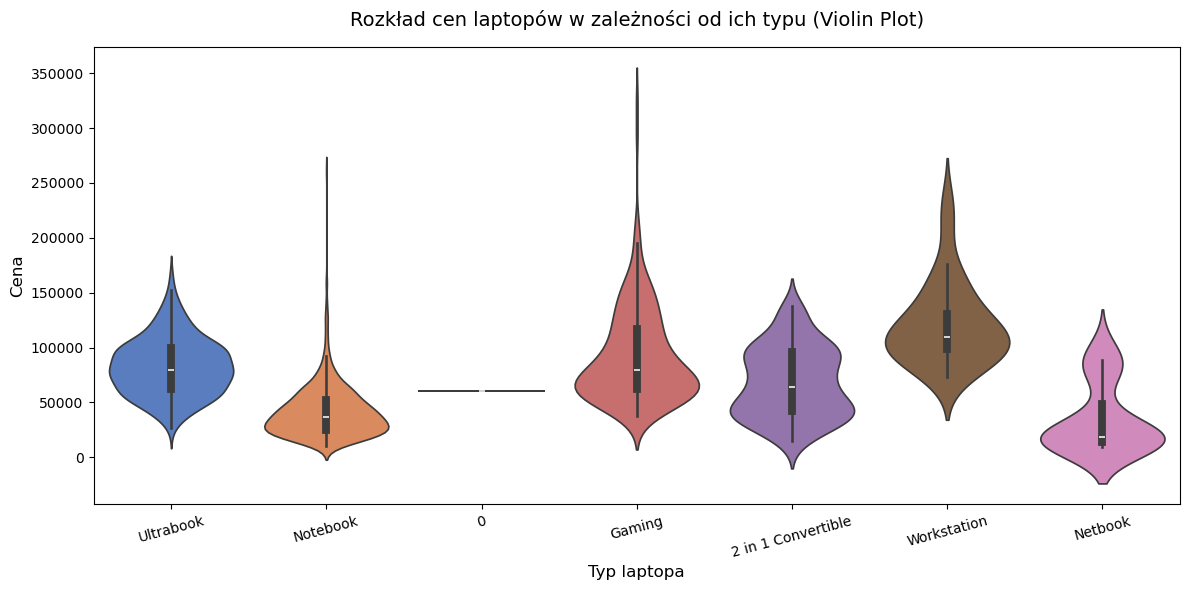

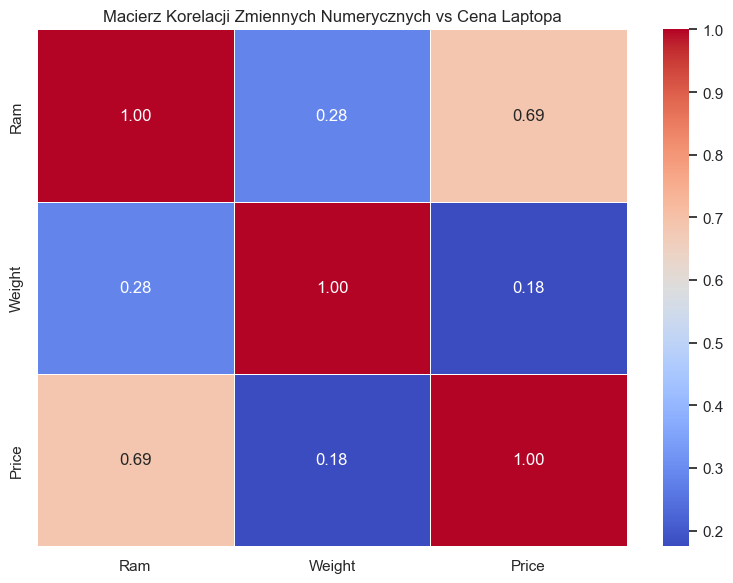

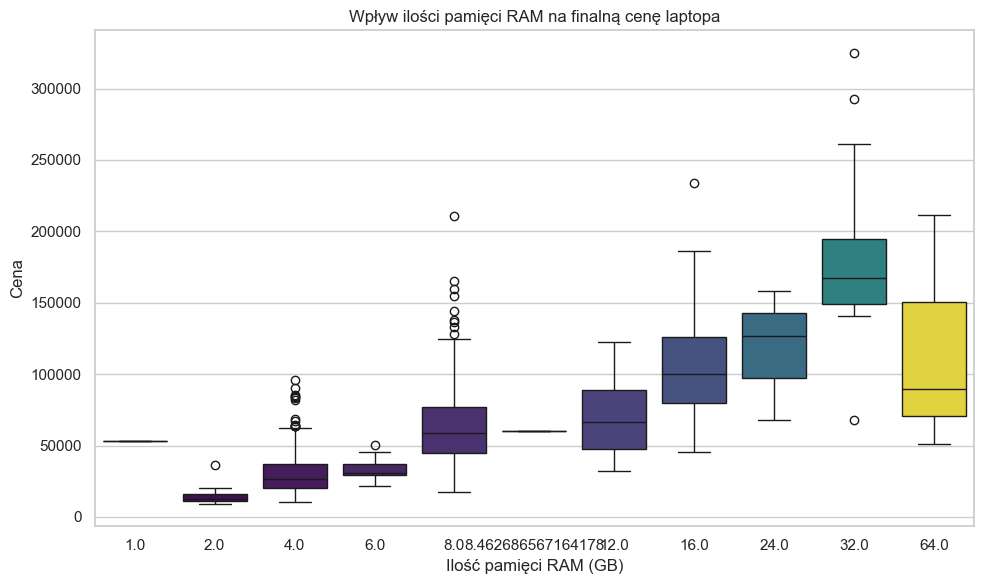

Próbka z przetworzonej w pełni macierzy:


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Touchscreen,IPS_Panel,Pixels_Total,Cpu_GHz,SSD_GB,HDD_GB
0,2,5,8,24,66,8.0,5,59,9,1.37,0,1,4096000.0,2.3,128,0
1,2,5,8,2,64,8.0,3,52,9,1.34,0,0,1296000.0,1.8,0,0
2,8,4,15,9,75,8.0,17,54,5,1.86,0,0,2073600.0,2.5,256,0
3,2,5,14,26,86,16.0,30,10,9,1.83,0,1,5184000.0,2.7,512,0
4,2,5,8,24,68,8.0,17,60,9,1.37,0,1,4096000.0,3.1,256,0


   PODSUMOWANIE PROCESU PRZETWARZANIA DANYCH
Wymiary zbioru przed: (1303, 12)  ->  Po przygotowaniu (X): (1303, 16)
Suma brakujących wartości przed: 360  ->  Po przetworzeniu: 0
Kolumny tekstowe przed: 10  ->  Po LabelEncoder: 0 (wszystkie zmienne są numeryczne)
       WYNIKI TESTU STATYSTYCZNEGO (OpSys vs Price)
Statystyka testu H Kruskala-Wallisa: 181.5509
Wartość p-value: 2.4035e-34
Wniosek: Różnice w cenach laptopów pomiędzy różnymi systemami operacyjnymi są ISTOTNE statystycznie.
Odrzucamy hipotezę zerową na rzecz hipotezy alternatywnej. System ma znaczenie!


In [1]:
import re
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder


# Wczytujemy dane z plik csv i od razu pozbywamy się ewentualnych śmieci
df = pd.read_csv('data\laptopy.csv')

# Zapisujemy stan początkowy do porównania
oryginalny_ksztalt = df.shape
oryginalne_braki = df.isnull().sum().sum()
liczba_tekstowych_przed = len(df.select_dtypes(include=['object']).columns)

 
# Usuwamy niepotrzebna kolumna z indeksem ('Unnamed: 0') dla zachowania przejrzystości.
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)


# Czyszczenie danych (data cleaning).
# Kolumny 'Ram' i 'Weight' są wczytywane jako typ tekstowy, 
# ponieważ zawierają jednostki miar ("GB" oraz "kg"), a czasami braki lub błędne znaki (np. "?").

# Kolumna 'Ram' usuwamy tekst "GB" i od razu wymuszamy konwersję do typu zmiennoprzecinkowego.
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False)
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')

# Kolumna 'Weight' usuwamy tekst "kg". 
# Każda wartość, której nie da się przerobić na liczbę (np. "?"), zostanie automatycznie zamieniona na brakujące dane (NaN).
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')


# Uzupełnianie brakujących danych (KNN imputer)

# Automatycznie filtrujemy z ramki wyłącznie kolumny numeryczne.
num_cols = df.select_dtypes(include=[np.number]).columns

# Inicjalizujemy KNNImputer
# 5 najbliższych sąsiadów to optymalny punkt wyjścia.
imputer = KNNImputer(n_neighbors=5, weights='distance')

# Uzupełniamy nasze kolumny (np. ewentualne wartości NaN w kolumnie 'Weight')
df[num_cols] = imputer.fit_transform(df[num_cols])

# ==========================================
# KROK 1: ZAAWANSOWANA INŻYNIERIA CECH
# ==========================================

# 1. Ekran: IPS oraz dotyk (używamy na=False by uniknąć błędów)
df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen', case=False, na=False).astype(int)
df['IPS_Panel'] = df['ScreenResolution'].str.contains('IPS Panel', case=False, na=False).astype(int)

# Wyciągamy całkowitą liczbę pikseli
def extract_pixels(text):
    match = re.search(r'(\d+)x(\d+)', str(text))
    if match:
        return int(match.group(1)) * int(match.group(2))
    return np.nan

df['Pixels_Total'] = df['ScreenResolution'].apply(extract_pixels)

# 2. Procesor: Wyciągamy czyste taktowanie w GHz
df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)

# 3. Pamięć: Rozdzielamy na SSD i HDD (w GB)
def get_storage_gb(text, storage_type):
    text = str(text)
    if storage_type not in text:
        return 0
    match = re.search(r'(\d+)(GB|TB)\s+' + storage_type, text)
    if match:
        val = int(match.group(1))
        if match.group(2) == 'TB':
            val *= 1024
        return val
    return 0

df['SSD_GB'] = df['Memory'].apply(lambda x: get_storage_gb(x, 'SSD'))
df['HDD_GB'] = df['Memory'].apply(lambda x: get_storage_gb(x, 'HDD'))

# Uzupełniamy ewentualne braki (np. procesor bez podanego taktowania)
df.fillna(0, inplace=True)
print("KROK 1: Dodano numeryczne cechy: Touchscreen, IPS_Panel, Pixels_Total, Cpu_GHz, SSD_GB, HDD_GB.")


# ==========================================
# KROK 2: WYKRES SKRZYPCOWY (VIOLIN PLOT)
# ==========================================
plt.figure(figsize=(12, 6))
# Tworzymy estetyczny wykres przed zakodowaniem zmiennych, by kategorie były czytelne
sns.violinplot(data=df, x='TypeName', y='Price', hue='TypeName', palette='muted', legend=False)

plt.title("Rozkład cen laptopów w zależności od ich typu (Violin Plot)", fontsize=14, pad=15)
plt.xlabel("Typ laptopa", fontsize=12)
plt.ylabel("Cena", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Wizualizacja danych
sns.set_theme(style="whitegrid")

# Wykres_1 - macierz korelacji (Heatmap)
plt.figure(figsize=(8, 6))
# Liczymy korelację tylko pośród naszych imputowanych cech numerycznych
corr_matrix = df[num_cols].corr()

# Używamy przejrzystej mapy kolorów 'coolwarm' dla łatwego wyłapania siły związków w raporcie
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Macierz Korelacji Zmiennych Numerycznych vs Cena Laptopa")
plt.tight_layout()
plt.show()

# Wykres_2 - rozkład cen w zależności od ilości pamięci RAM (Boxplot)
plt.figure(figsize=(10, 6))
# Boxplot wskaże nie tylko trend wzrostowy, ale także wartości odstające (outliers)
sns.boxplot(data=df, x='Ram', y='Price', hue='Ram', palette='viridis', legend=False)
plt.title("Wpływ ilości pamięci RAM na finalną cenę laptopa")
plt.xlabel("Ilość pamięci RAM (GB)")
plt.ylabel("Cena")
plt.tight_layout()
plt.show()

# Przygotowanie zmiennych kategorycznych pod model ML.
# Aby algorytm ML zrozumiał zmienne takie jak nazwa firmy czy procesor, 
# przeprowadzamy ich transformację korzystając z automatycznej pętli z klasą LabelEncoder.

cat_cols = df.select_dtypes(include=['object']).columns

# Przetrzymujemy obiekty encodera w słowniku, 
# gdybyś w przyszłości (produkcyjnie) musiał odkodować zmienne (inverse_transform).
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Rzutujemy na ciąg tekstowy (.astype(str)), żeby ustrzec się błędu dla ukrytych typów
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


# Tworzenie "Feature Matrix" (X) oraz targetu, który chcemy przewidzieć (y)
X = df.drop(columns=['Price'])
y = df['Price']

print("Próbka z przetworzonej w pełni macierzy:")
display(X.head())

# porównamy zbiory surowy i po oczyszczeniu i uzupełnieniu wartości
print("==================================================")
print("   PODSUMOWANIE PROCESU PRZETWARZANIA DANYCH")
print("==================================================")
print(f"Wymiary zbioru przed: {oryginalny_ksztalt}  ->  Po przygotowaniu (X): {X.shape}")
print(f"Suma brakujących wartości przed: {oryginalne_braki}  ->  Po przetworzeniu: {X.isnull().sum().sum()}")
print(f"Kolumny tekstowe przed: {liczba_tekstowych_przed}  ->  Po LabelEncoder: 0 (wszystkie zmienne są numeryczne)")
print("==================================================")


# ==========================================
# KROK 3: TEST STATYSTYCZNY (Kruskal-Wallis)
# ==========================================
# Sprawdzamy, czy system operacyjny wpływa w istotny sposób na cenę laptopa.

# Przygotowanie zgrupowanych list z cenami dla każdego systemu operacyjnego
systems = df['OpSys'].unique()
prices_by_system = [df[df['OpSys'] == sys]['Price'].dropna() for sys in systems]

# Wykonanie testu
stat, p_value = stats.kruskal(*prices_by_system)

print("==================================================")
print("       WYNIKI TESTU STATYSTYCZNEGO (OpSys vs Price)")
print("==================================================")
print(f"Statystyka testu H Kruskala-Wallisa: {stat:.4f}")
print(f"Wartość p-value: {p_value:.4e}")
print("==================================================")

# Interpretacja wyniku (poziom istotności 5%)
alpha = 0.05
if p_value < alpha:
    print("Wniosek: Różnice w cenach laptopów pomiędzy różnymi systemami operacyjnymi są ISTOTNE statystycznie.")
    print("Odrzucamy hipotezę zerową na rzecz hipotezy alternatywnej. System ma znaczenie!")
else:
    print("Wniosek (Brak sukcesu): Brak statystycznie istotnych różnic w cenach pomiędzy systemami operacyjnymi.")
    print("Nie ma podstaw do odrzucenia hipotezy zerowej. To również bardzo cenny wynik analityczny!")
